# Experiment 1: Fundamental Image Processing Operations


#### Name- Abhigyan Dubey
#### Course & Branch- B.TECH CSE
#### CUID- CU24250059
#### SUBJECT - Computer Vision Lab
#### SEM & Section - 5th SEM , "B"


**Before running:** Just put location of the img in the IMAGE_PATH, Using Python, OpenCV, NumPy, and Matplotlib

## Step 1: Import libraries

- **cv2** (OpenCV) — does the actual image processing: reading, writing, converting, resizing, rotating, etc.
- **numpy** — an image is just a big grid (array) of numbers (pixel values); numpy lets us do math on that array.
- **matplotlib.pyplot** — used to *display* images as plots (with titles, side-by-side comparisons) — works better in notebooks than OpenCV's own popup windows.
- **os** — just for building file paths safely.

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

IMAGE_PATH = "d:\Downloads\Wallpaper1\Honkai-Star-Rail-Aventurine-materials,-kit,-and-Eidolons-cover.png"   # change this if your image has a different name
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Step 2: Load and display the image

`cv2.imread()` reads the image from disk into a NumPy array.

**Important quirk:** OpenCV loads colors as **BGR** (Blue-Green-Red), not the usual RGB order. This trips up almost every beginner. If we plot a BGR array directly with Matplotlib (which expects RGB), the colors look wrong — reds and blues get swapped. So before displaying with Matplotlib, we convert BGR → RGB using `cv2.cvtColor()`.

*(Note: in a notebook we skip `cv2.imshow()`, since it opens a native OS window that doesn't play well with Jupyter — we just use Matplotlib throughout.)*

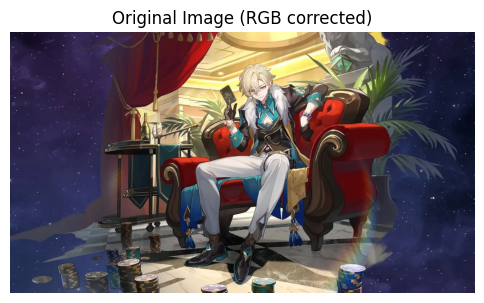

In [15]:
from pathlib import Path

img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    image_path = Path(IMAGE_PATH)

    if not image_path.is_absolute():
        image_path = Path.cwd() / image_path

    raise FileNotFoundError(
        f"Image not found: {image_path}\n"
        f"Current working directory: {Path.cwd()}\n"
        "Update IMAGE_PATH to the correct image filename or full path."
    )

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Original Image (RGB corrected)")
plt.axis("off")
plt.show()

## Step 3: Examine image properties

`img.shape` returns `(height, width, channels)` for a color image.
`img.dtype` tells us the data type of each pixel value — normally `uint8`, meaning each channel value ranges from 0 to 255.

In [16]:
height, width, channels = img_bgr.shape

print("Width        :", width, "pixels")
print("Height       :", height, "pixels")
print("Channels     :", channels, " (3 = color BGR, 1 = grayscale)")
print("Data type    :", img_bgr.dtype)
print("Total pixels :", width * height)

Width        : 1380 pixels
Height       : 776 pixels
Channels     : 3  (3 = color BGR, 1 = grayscale)
Data type    : uint8
Total pixels : 1070880


## Step 4: Save in different formats and compare

`cv2.imwrite(path, image)` saves an array back to disk as an image file.

- **JPEG** — lossy compression: smaller file, slight quality loss, no transparency support.
- **PNG** — lossless compression: larger file, perfect quality, supports transparency.

In [17]:
jpg_path = os.path.join(OUTPUT_DIR, "saved_image.jpg")
png_path = os.path.join(OUTPUT_DIR, "saved_image.png")

cv2.imwrite(jpg_path, img_bgr)
cv2.imwrite(png_path, img_bgr)

jpg_size_kb = os.path.getsize(jpg_path) / 1024
png_size_kb = os.path.getsize(png_path) / 1024

print(f"JPEG file size : {jpg_size_kb:.2f} KB")
print(f"PNG file size  : {png_size_kb:.2f} KB")

JPEG file size : 311.22 KB
PNG file size  : 1387.54 KB


## Step 5: Color space conversions — Grayscale, HSV, LAB

- **Grayscale** — collapses 3 color channels into 1 brightness/intensity channel. Simpler and faster to process, but loses color info.
- **HSV** (Hue, Saturation, Value) — separates *color type* from *brightness*. Useful for detecting objects by color regardless of lighting changes.
- **LAB** — L (lightness), A (green–red), B (blue–yellow). Designed to match human color perception; useful for color correction.

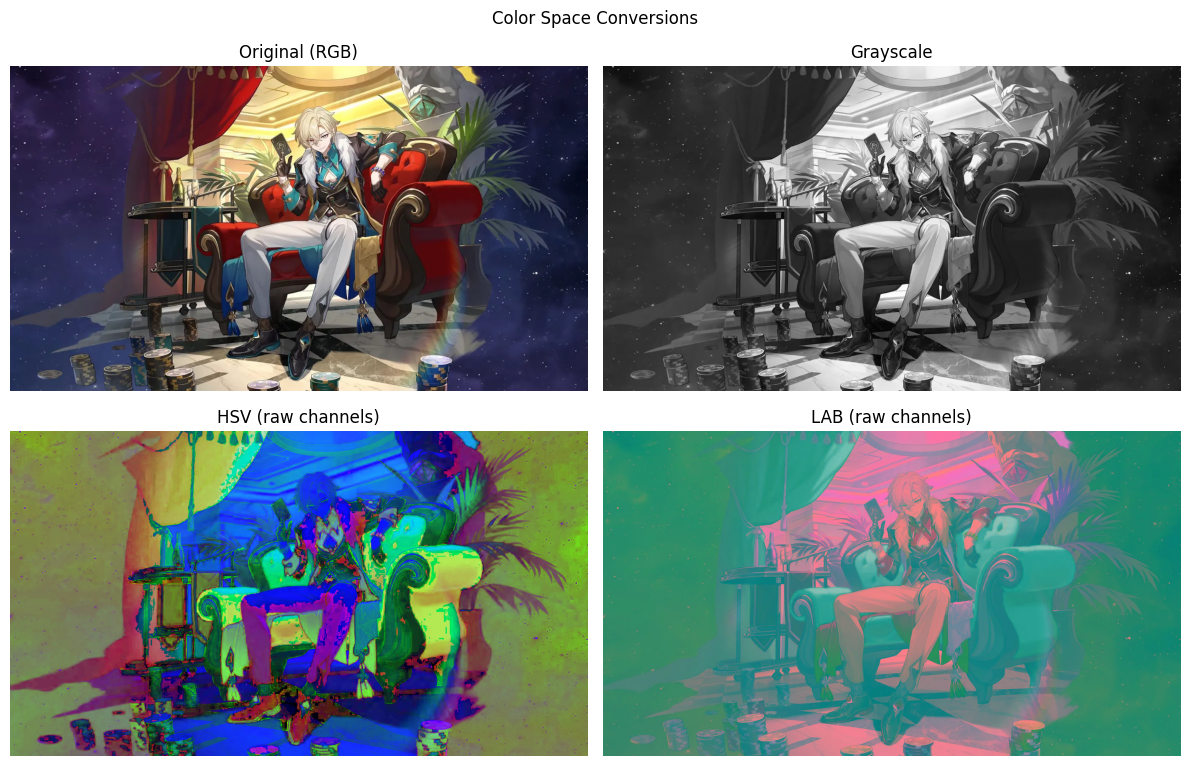

In [18]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
lab  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1); plt.imshow(img_rgb); plt.title("Original (RGB)"); plt.axis("off")
plt.subplot(2, 2, 2); plt.imshow(gray, cmap="gray"); plt.title("Grayscale"); plt.axis("off")
plt.subplot(2, 2, 3); plt.imshow(hsv); plt.title("HSV (raw channels)"); plt.axis("off")
plt.subplot(2, 2, 4); plt.imshow(lab); plt.title("LAB (raw channels)"); plt.axis("off")

plt.suptitle("Color Space Conversions")
plt.tight_layout()
plt.show()

## Step 6: Geometric transformations — resize, rotate, flip

- **Resize**: `cv2.resize(image, (new_width, new_height))`
- **Rotate**: build a rotation matrix around a center point with `cv2.getRotationMatrix2D()`, then apply it with `cv2.warpAffine()`.
- **Flip**: `cv2.flip(image, flip_code)` — `1` = horizontal mirror, `0` = vertical mirror, `-1` = both.

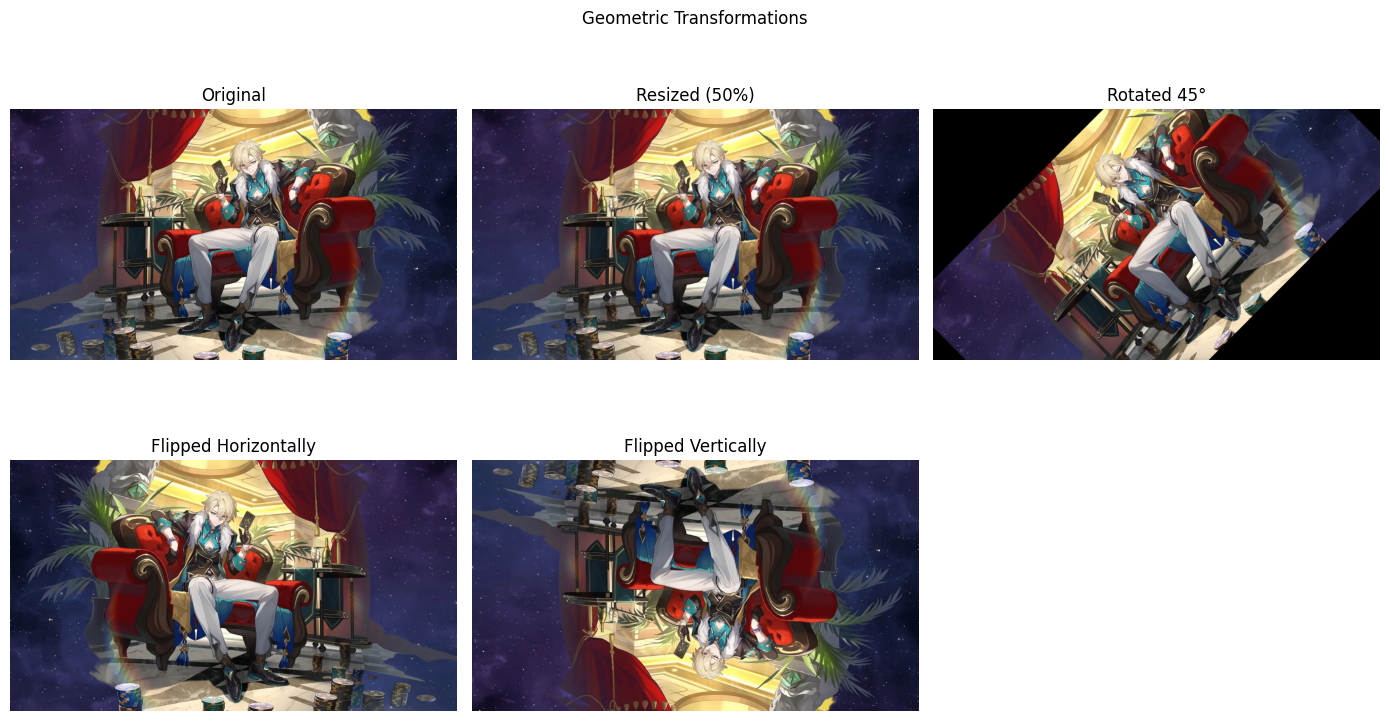

In [19]:
# Resize to half the original size
resized = cv2.resize(img_bgr, (width // 2, height // 2))

# Rotate 45 degrees around the center
center = (width // 2, height // 2)
angle = 45
scale = 1.0
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
rotated = cv2.warpAffine(img_bgr, rotation_matrix, (width, height))

# Flip horizontally and vertically
flipped_h = cv2.flip(img_bgr, 1)
flipped_v = cv2.flip(img_bgr, 0)

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1); plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
plt.subplot(2, 3, 2); plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)); plt.title("Resized (50%)"); plt.axis("off")
plt.subplot(2, 3, 3); plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)); plt.title("Rotated 45°"); plt.axis("off")
plt.subplot(2, 3, 4); plt.imshow(cv2.cvtColor(flipped_h, cv2.COLOR_BGR2RGB)); plt.title("Flipped Horizontally"); plt.axis("off")
plt.subplot(2, 3, 5); plt.imshow(cv2.cvtColor(flipped_v, cv2.COLOR_BGR2RGB)); plt.title("Flipped Vertically"); plt.axis("off")

plt.suptitle("Geometric Transformations")
plt.tight_layout()
plt.show()

## Step 7: Image complement / negative

For an 8-bit image, every pixel value is between 0 and 255. The negative of a pixel is simply `255 - original_value`. Bright areas become dark, dark areas become bright, and colors invert.

NumPy lets us apply this to the **whole array at once** — no loops needed.

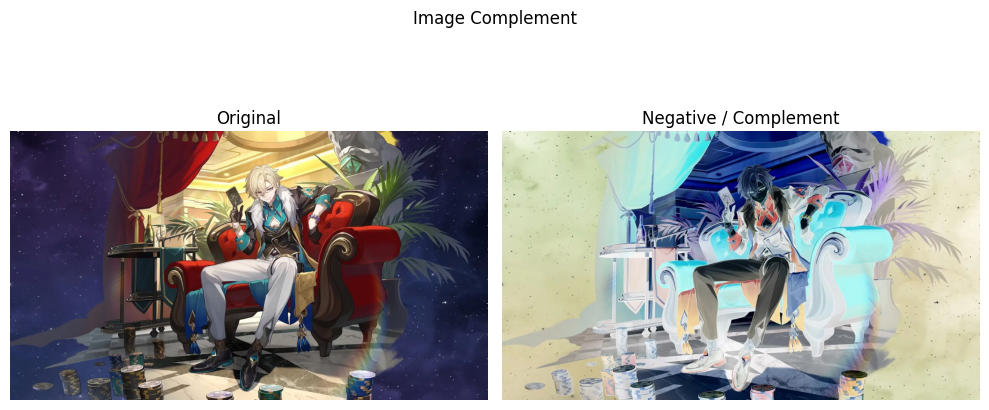

In [20]:
negative = 255 - img_bgr

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(negative, cv2.COLOR_BGR2RGB)); plt.title("Negative / Complement"); plt.axis("off")
plt.suptitle("Image Complement")
plt.tight_layout()
plt.show()

## Step 8: Crop a Region of Interest (ROI)

An image is just a NumPy array, so cropping is simply array slicing: `img[y_start:y_end, x_start:x_end]`.

Remember: **rows = height (y-axis), columns = width (x-axis)**.

Below we crop the center quarter of the image as an example — change the numbers to grab whichever region you actually want (e.g. a face, an object).

ROI shape: (388, 690, 3)  (height, width, channels)


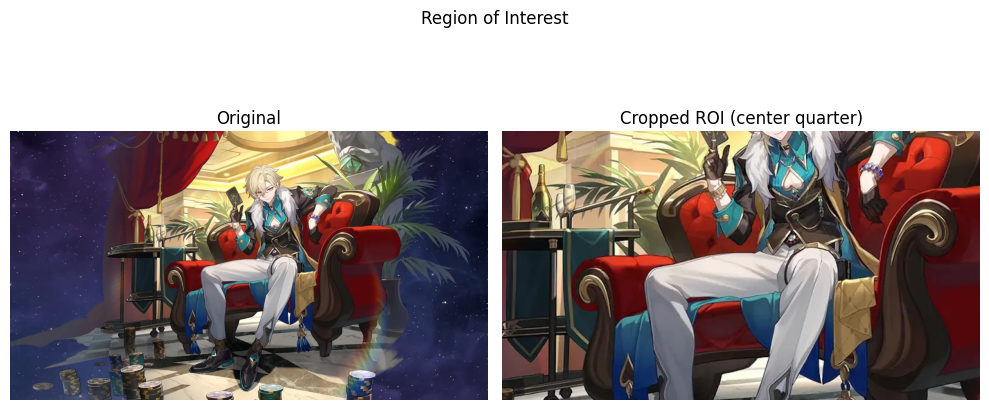

In [21]:
y_start, y_end = height // 4, (height * 3) // 4
x_start, x_end = width // 4, (width * 3) // 4
roi = img_bgr[y_start:y_end, x_start:x_end]

print("ROI shape:", roi.shape, " (height, width, channels)")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)); plt.title("Cropped ROI (center quarter)"); plt.axis("off")
plt.suptitle("Region of Interest")
plt.tight_layout()
plt.show()

## Step 9: Save processed outputs

Good practice: save your processed images to disk so you can attach them to your lab report.

In [13]:
cv2.imwrite(os.path.join(OUTPUT_DIR, "gray.png"), gray)
cv2.imwrite(os.path.join(OUTPUT_DIR, "negative.png"), negative)
cv2.imwrite(os.path.join(OUTPUT_DIR, "roi.png"), roi)
cv2.imwrite(os.path.join(OUTPUT_DIR, "rotated.png"), rotated)

print(f"Processed images saved inside the '{OUTPUT_DIR}/' folder.")
print("Done! Use the plots and printed properties above for your lab record / observations.")

Processed images saved inside the 'outputs/' folder.
Done! Use the plots and printed properties above for your lab record / observations.


## Key takeaways

- **BGR vs RGB**: OpenCV stores color images as Blue-Green-Red, not Red-Green-Blue. Always convert with `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` before displaying via Matplotlib.
- **An image is just a NumPy array**: that's why cropping (`img[y1:y2, x1:x2]`) and negation (`255 - img`) are one-liners. Once this clicks, a lot of "image processing" stops feeling mysterious and just becomes array math.